<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/FIRe_pH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:96: SyntaxWarning: invalid escape sequence '\s'
<>:96: SyntaxWarning: invalid escape sequence '\s'
<>:96: SyntaxWarning: invalid escape sequence '\s'
<>:96: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3277732794.py:96: SyntaxWarning: invalid escape sequence '\s'
  {"col": "Sigma", "ylabel": "$\sigma_{PSII}$ ($\AA^2$)", "title": "Effective Cross-section ($\sigma_{PSII}$)\nunder different pH conditions", "tick_spacing": 200.0}
/tmp/ipython-input-3277732794.py:96: SyntaxWarning: invalid escape sequence '\s'
  {"col": "Sigma", "ylabel": "$\sigma_{PSII}$ ($\AA^2$)", "title": "Effective Cross-section ($\sigma_{PSII}$)\nunder different pH conditions", "tick_spacing": 200.0}



Analysis for Fm:
         Factor   P-value Significance
0        Morph  0.489254           ns
1           pH  0.000177          ***
2  Interaction  0.331642           ns


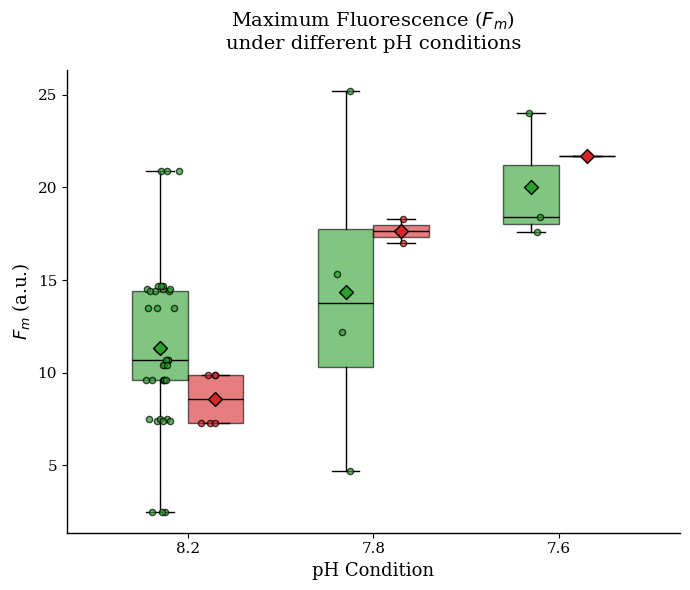


Analysis for fv_fm:
         Factor   P-value Significance
0        Morph  0.957269           ns
1           pH  0.101046           ns
2  Interaction  0.549688           ns


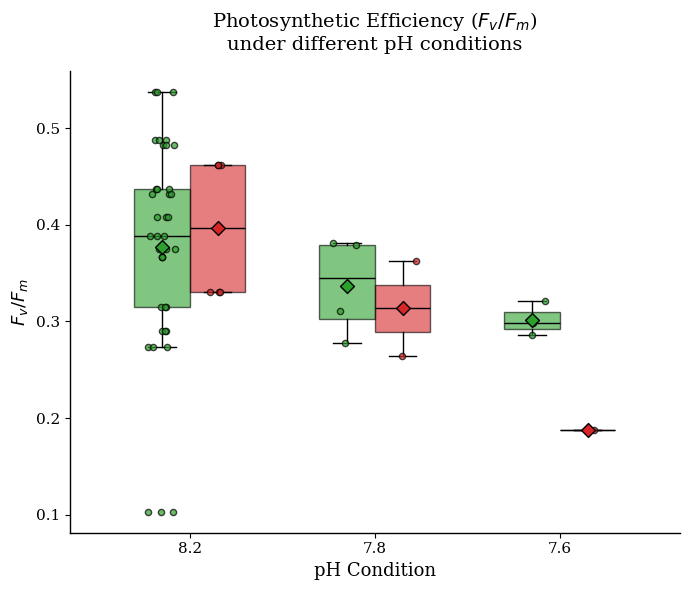


Analysis for Pmax.e.s:
         Factor   P-value Significance
0        Morph  0.266891           ns
1           pH  0.112975           ns
2  Interaction  0.429012           ns


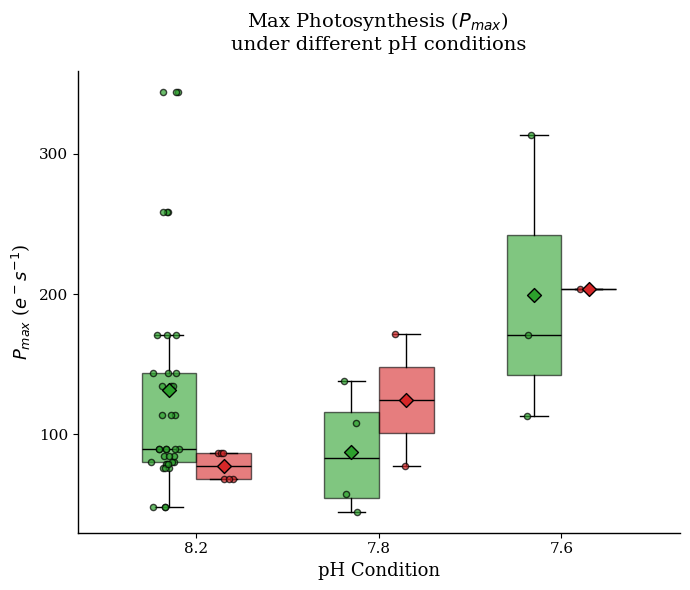


Analysis for p:
         Factor   P-value Significance
0        Morph  0.989101           ns
1           pH  0.029593            *
2  Interaction  0.581665           ns


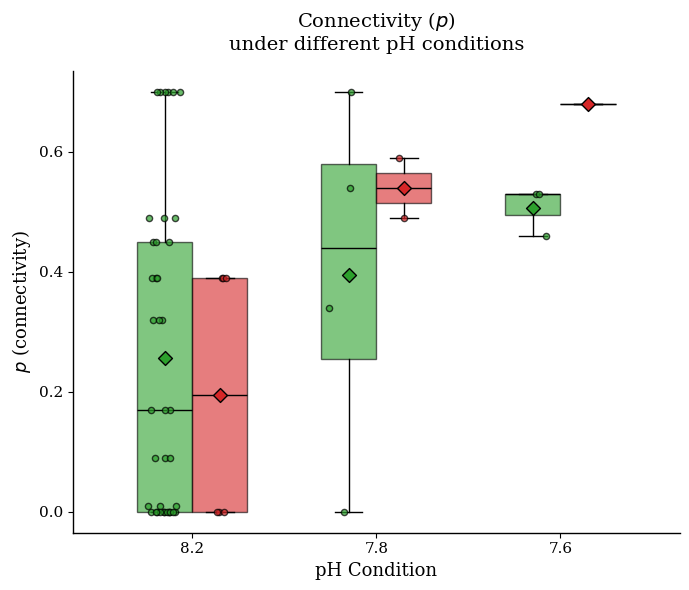


Analysis for Sigma:
         Factor   P-value Significance
0        Morph  0.071220           ns
1           pH  0.516760           ns
2  Interaction  0.722205           ns


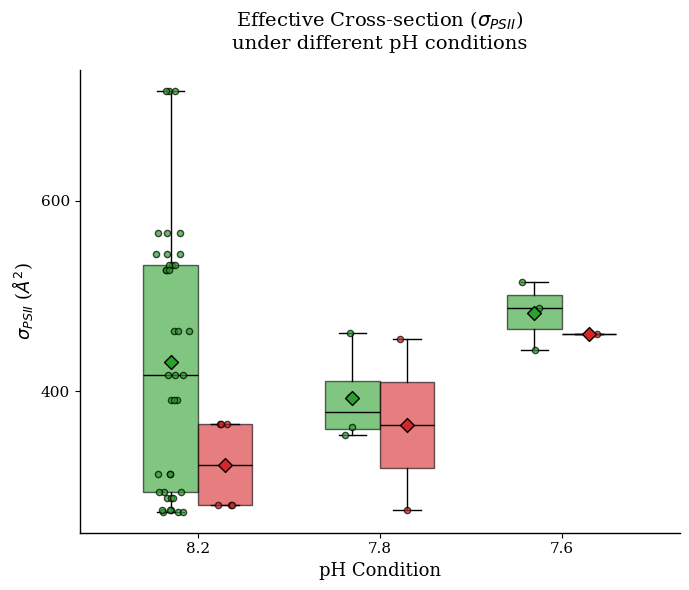

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ==========================================
# 1. GLOBAL SETUP & DATA LOADING
# ==========================================
filename = "FIRe_2025_pH.csv"
df = pd.read_csv(filename)

# Clean columns
df.columns = df.columns.str.strip()
if 'Site' in df.columns:
    df = df.rename(columns={'Site': 'morph'})
df['morph'] = df['morph'].str.strip()

# Clean pH column and set order (8.2 is typical ambient)
df['pH'] = df['pH'].astype(str).str.strip()
ph_order = ["8.2", "7.8", "7.6"]
df = df[df['pH'].isin(ph_order)]

# --- DATA CLEANING (Global Filters) ---
if 'p' in df.columns:
    df = df[df['p'] <= 0.8].copy()

if 'Pmax.e.s' in df.columns:
    df = df[df['Pmax.e.s'] <= 450].copy()

if 'Sigma' in df.columns:
    df = df[df['Sigma'] <= 850].copy()

if 'fv_fm' in df.columns:
    df = df[df['fv_fm'] > 0].copy()

# Style Settings
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

def generate_stats_table_2way(dataframe, col):
    """Calculates Two-Way ANOVA stats for pH and Morph."""
    try:
        model = ols(f"Q('{col}') ~ C(morph) + C(pH) + C(morph):C(pH)", data=dataframe).fit()
        anova = sm.stats.anova_lm(model, typ=2)
        p_morph = anova.loc['C(morph)', 'PR(>F)']
        p_ph = anova.loc['C(pH)', 'PR(>F)']
        p_inter = anova.loc['C(morph):C(pH)', 'PR(>F)']

        return pd.DataFrame({
            'Factor': ['Morph', 'pH', 'Interaction'],
            'P-value': [p_morph, p_ph, p_inter],
            'Significance': [
                "ns" if p >= 0.05 else ("*" if p >= 0.01 else ("**" if p >= 0.001 else "***"))
                for p in [p_morph, p_ph, p_inter]
            ]
        })
    except Exception as e:
        return pd.DataFrame({'Error': [str(e)]})

def generate_tukey_hsd_table(dataframe, col_name):
    """Calculates Tukey's HSD post-hoc test."""
    try:
        df_tukey = dataframe.copy()
        df_tukey['group'] = df_tukey['morph'].astype(str) + '_' + df_tukey['pH'].astype(str)
        if df_tukey['group'].nunique() > 1:
            tukey_results = pairwise_tukeyhsd(endog=df_tukey[col_name], groups=df_tukey['group'], alpha=0.05)
            tukey_df = pd.DataFrame(data=tukey_results._results_table.data[1:], columns=tukey_results._results_table.data[0])
            tukey_df['reject'] = tukey_df['reject'].apply(lambda x: 'Yes' if x else 'No')
            return tukey_df
        else:
            return pd.DataFrame({'Note': ['Not enough groups for Tukey HSD.']})
    except Exception as e:
        return pd.DataFrame({'Error': [str(e)]})

# Plot Configuration for the pH dataset
plots_config = [
    {"col": "Fm", "ylabel": "$F_m$ (a.u.)", "title": "Maximum Fluorescence ($F_m$)\nunder different pH conditions", "tick_spacing": 5.0},
    {"col": "fv_fm", "ylabel": "$F_v/F_m$", "title": "Photosynthetic Efficiency ($F_v/F_m$)\nunder different pH conditions", "tick_spacing": 0.1},
    {"col": "Pmax.e.s", "ylabel": "$P_{max}$ ($e^- s^{-1}$)", "title": "Max Photosynthesis ($P_{max}$) \nunder different pH conditions", "tick_spacing": 100.0},
    {"col": "p", "ylabel": "$p$ (connectivity)", "title": "Connectivity ($p$)\nunder different pH conditions", "tick_spacing": 0.2},
    {"col": "Sigma", "ylabel": "$\sigma_{PSII}$ ($\AA^2$)", "title": "Effective Cross-section ($\sigma_{PSII}$)\nunder different pH conditions", "tick_spacing": 200.0}
]

for config in plots_config:
    col = config["col"]
    if col not in df.columns: continue

    sub = df.dropna(subset=[col, 'morph', 'pH'])
    sub = sub[sub['morph'].isin(morph_order)]

    # Statistics
    stats_df = generate_stats_table_2way(sub, col)
    print(f"\nAnalysis for {col}:\n", stats_df)

    # Plotting
    fig, ax = plt.subplots(figsize=(7, 6))
    box_width, x_pos = 0.6, np.arange(len(ph_order))
    offset = box_width / 4

    # HF Boxes
    hf_data = [sub[(sub['pH']==p) & (sub['morph']=='HF')][col].values for p in ph_order]
    bp1 = ax.boxplot(hf_data, positions=x_pos - offset, widths=box_width/2, patch_artist=True, showfliers=False)
    for patch in bp1['boxes']:
        patch.set(facecolor=variant_colors['HF'], alpha=0.6, edgecolor='black')
    plt.setp(bp1['medians'], color='black')

    # NF Boxes
    nf_data = [sub[(sub['pH']==p) & (sub['morph']=='NF')][col].values for p in ph_order]
    bp2 = ax.boxplot(nf_data, positions=x_pos + offset, widths=box_width/2, patch_artist=True, showfliers=False)
    for patch in bp2['boxes']:
        patch.set(facecolor=variant_colors['NF'], alpha=0.6, edgecolor='black')
    plt.setp(bp2['medians'], color='black')

    # Scatter & Means
    for i, ph_val in enumerate(ph_order):
        for m, off in [('HF', -offset), ('NF', offset)]:
            y = sub[(sub['pH']==ph_val) & (sub['morph']==m)][col]
            ax.scatter(np.random.normal(i + off, 0.04, size=len(y)), y, s=20, color=variant_colors[m], edgecolors='black', alpha=0.7, zorder=3)
            ax.scatter(i + off, y.mean(), marker='D', s=50, color=variant_colors[m], edgecolors='black', zorder=4)

    # Formatting
    ax.set_ylabel(config["ylabel"], fontsize=13)
    ax.set_xlabel("pH Condition", fontsize=13)
    ax.set_title(config["title"], fontsize=14, pad=15)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(ph_order)

    # Significance Annotation
    p_morph = stats_df.loc[stats_df['Factor']=='Morph', 'P-value'].values[0]
    if p_morph < 0.05:
        p_text = f"p(morph) = {p_morph:.3f}" if p_morph >= 0.001 else "p(morph) < 0.001"
        ax.text(0.95, 0.05, p_text, transform=ax.transAxes, ha='right', va='bottom', fontsize=10, style='italic')

    ax.yaxis.set_major_locator(ticker.MultipleLocator(config["tick_spacing"]))
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(f"FIRe_pH_{col}.png", dpi=300)
    plt.show()